# Lab of Large Numbers: Convergence Laboratory

## When does the LLN fail?
The **Law of Large Numbers** stats that the sample means converge to the population mean as n goes to infinity
**BUT ONLY when the variance is finite**
 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N=50_000

def running_mean(samples):
    #cumulative running mean
    return np.cumsum(samples)/np.arange(1,len(samples)+1)

## 1. Normal Distribution: Finite Variance
Mean=0, Variance=1 -> Smooth Convergence guaranteed

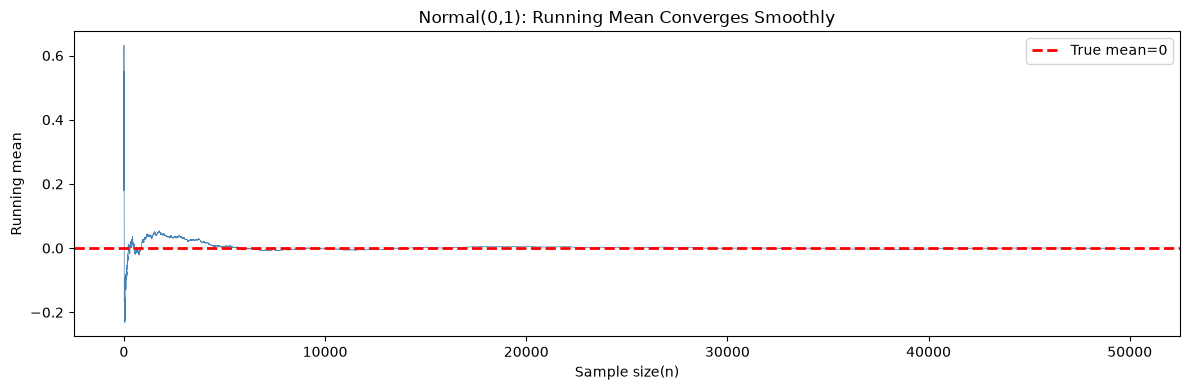

In [2]:
normal_samples = np.random.normal(0,1,N)

plt.figure(figsize=(12,4))
plt.plot(running_mean(normal_samples), lw=0.5, color='steelblue')
plt.axhline(0, color='red', ls='--', lw=2, label='True mean=0')
plt.xlabel('Sample size(n)')
plt.ylabel('Running mean')
plt.title('Normal(0,1): Running Mean Converges Smoothly')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Bernoulli Distribution - Finite Variance
rho=0.3, Variance=0.21 -> Smooth converence guaranteed

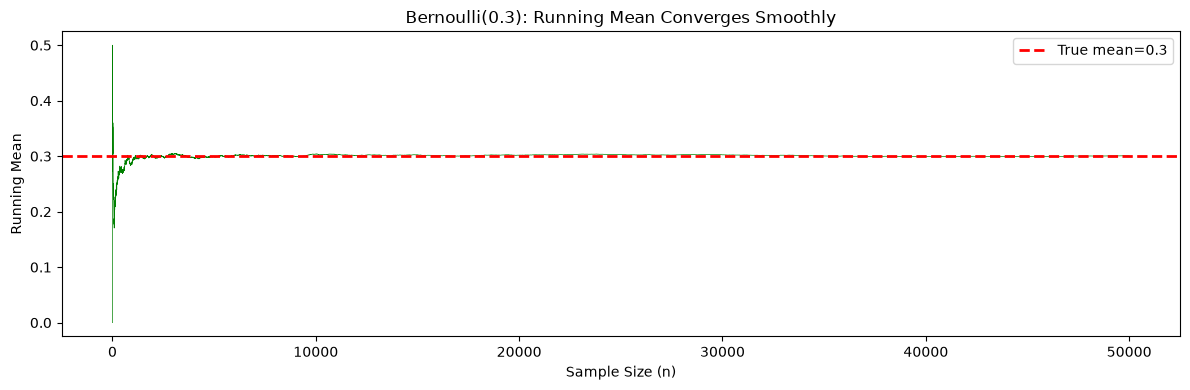

In [3]:
rho =0.3
bernoulli_samples = np.random.binomial(1, rho, N)

plt.figure(figsize=(12,4))
plt.plot(running_mean(bernoulli_samples), lw=0.5, color='green')
plt.axhline(rho, color='red', ls='--', lw=2,label=f'True mean={rho}')
plt.xlabel('Sample Size (n)')
plt.ylabel('Running Mean')
plt.title('Bernoulli(0.3): Running Mean Converges Smoothly')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Pareto Distribution - The critical Test

For Pareto:
- Mean: alpha/(alpha-1) when alpha > 1
- Variance: infinity when alpha <= 2 -> This Breaks LLN

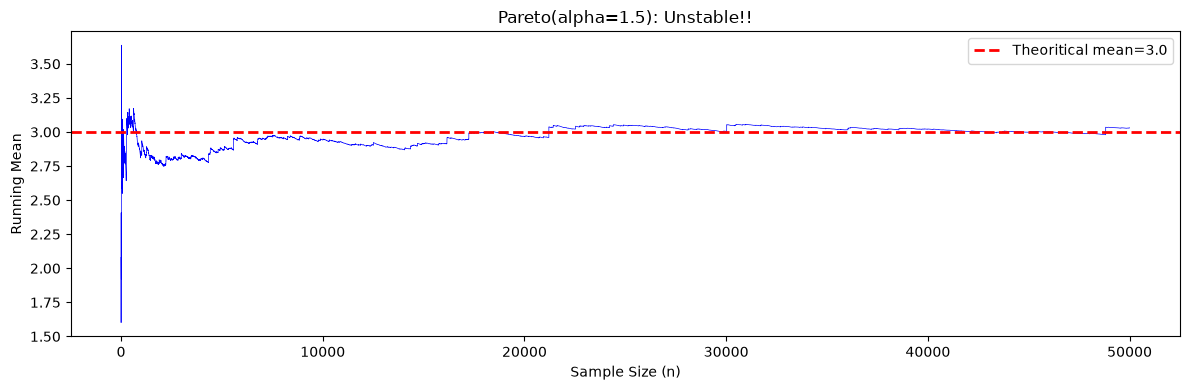

In [8]:
alpha = 1.5 #infinite variance
pareto_unstable = (np.random.pareto(alpha,N)+1)
true_mean = alpha/(alpha-1)

plt.figure(figsize=(12,4))
plt.plot(running_mean(pareto_unstable), lw=0.5, color='blue')
plt.axhline(true_mean, color='red', ls='--', lw=2,label=f'Theoritical mean={true_mean:.1f}')
plt.xlabel('Sample Size (n)')
plt.ylabel('Running Mean')
plt.title(f'Pareto(alpha={alpha}): Unstable!!')
plt.legend()
plt.tight_layout()
plt.show()

### Multiple Trials
Each realisation takes a completely different path: No convergence

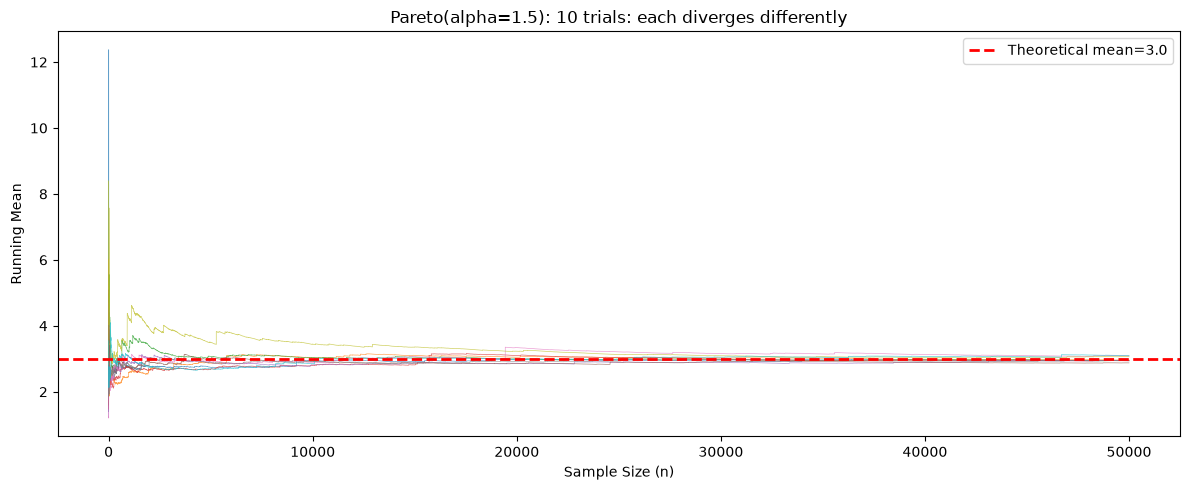

In [5]:
plt.figure(figsize=(12,5))
for trial in range(10):
    samples = (np.random.pareto(1.5,N)+1)
    plt.plot(running_mean(samples), alpha=0.7, lw=0.5)

plt.axhline(3.0, color='red', ls='--', lw=2, label='Theoretical mean=3.0')
plt.xlabel('Sample Size (n)')
plt.ylabel('Running Mean')
plt.title('Pareto(alpha=1.5): 10 trials: each diverges differently')
plt.legend()
plt.tight_layout()
plt.show()

### Case B : alpha=3
when alpha > 2, variance become finite and LLN works again

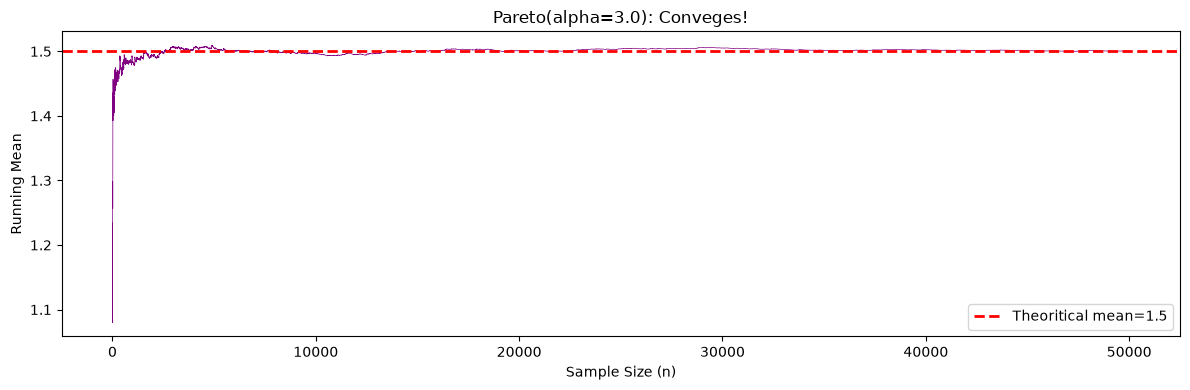

In [6]:
alpha_stable = 3.0
pareto_stable = (np.random.pareto(alpha_stable,N)+1)
true_mean_stable = alpha_stable/(alpha_stable-1)

plt.figure(figsize=(12,4))
plt.plot(running_mean(pareto_stable), lw=0.5, color='purple')
plt.axhline(true_mean_stable, color='red', ls='--', lw=2,label=f'Theoritical mean={true_mean_stable:.1f}')
plt.xlabel('Sample Size (n)')
plt.ylabel('Running Mean')
plt.title(f'Pareto(alpha={alpha_stable}): Conveges!')
plt.legend()
plt.tight_layout()
plt.show()

## Side-To-Side Comparison

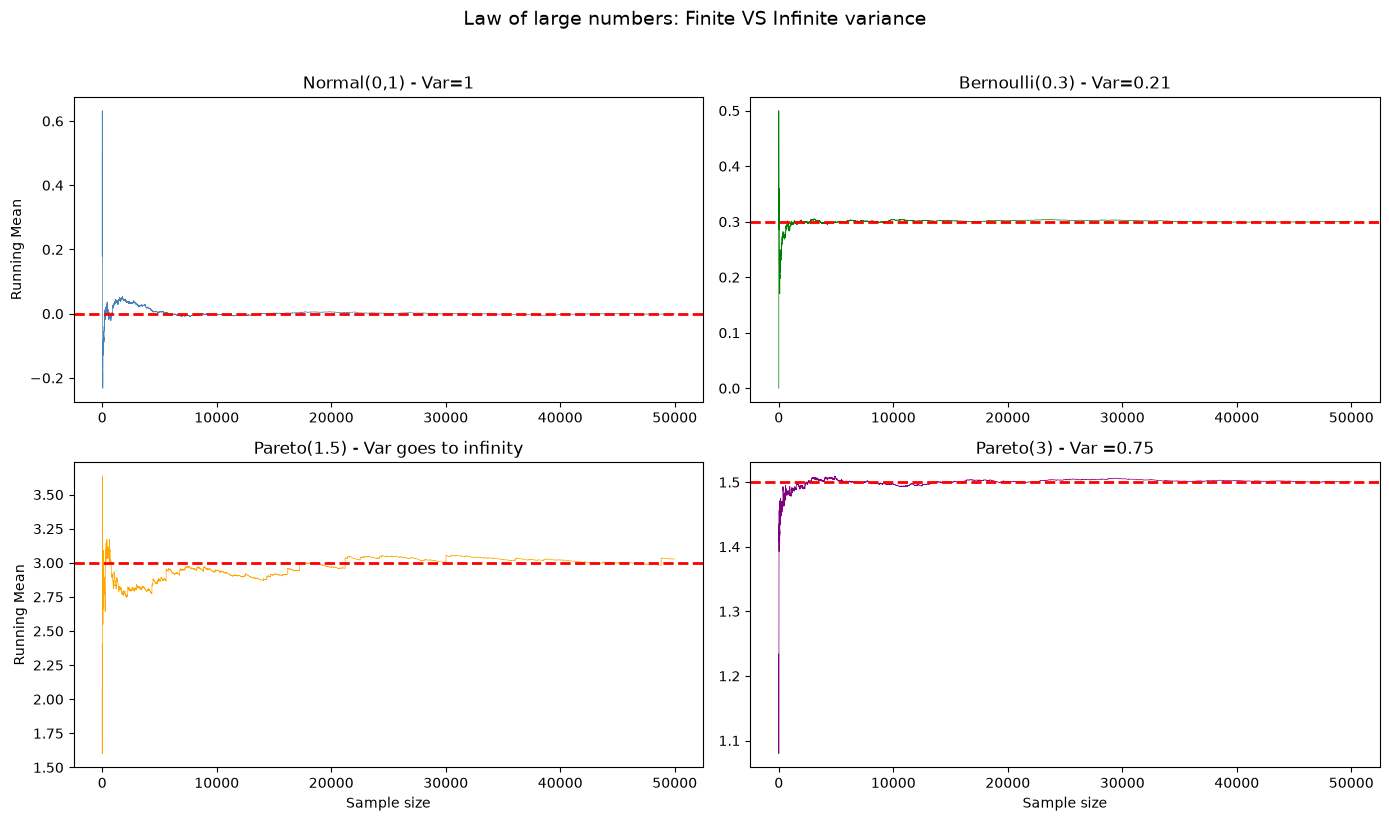

In [12]:
fig, axes = plt.subplots(2,2,figsize=(14,8))

# normal
axes[0,0].plot(running_mean(normal_samples), lw=0.5, color='steelblue')
axes[0,0].axhline(0, color='red', ls='--', lw=2)
axes[0,0].set_title('Normal(0,1) - Var=1', fontsize=12)
axes[0,0].set_ylabel('Running Mean')

# bernoulli
axes[0,1].plot(running_mean(bernoulli_samples), lw=0.5, color='green')
axes[0,1].axhline(0.3, color='red', ls='--', lw=2)
axes[0,1].set_title('Bernoulli(0.3) - Var=0.21', fontsize=12)

# Pareto Unstable
axes[1,0].plot(running_mean(pareto_unstable), lw=0.5, color='orange')
axes[1,0].axhline(3.0, color='red', ls='--', lw=2)
axes[1,0].set_title('Pareto(1.5) - Var goes to infinity', fontsize=12)
axes[1,0].set_xlabel('Sample size')
axes[1,0].set_ylabel('Running Mean')

# Pareto Stable
axes[1,1].plot(running_mean(pareto_stable), lw=0.5, color='purple')
axes[1,1].axhline(1.5, color='red', ls='--', lw=2)
axes[1,1].set_title('Pareto(3) - Var =0.75', fontsize=12)
axes[1,1].set_xlabel('Sample size')

plt.suptitle('Law of large numbers: Finite VS Infinite variance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

